{
  "best_params": {
    "lambda_over": 0.01,
    "lambda_under": 0.01,
    "theta_queue": 0.01
  },
  "smart_router": {
    "cash": 1113700.0,
    "avg_fill_price": 222.74
  },
  "best_ask": {
    "cash": 1114102.2800000003,
    "avg_fill_price": 222.82045600000006
  },
  "twap": {
    "cash": 432809.17000000004,
    "avg_fill_price": 86.561834
  },
  "vwap": {
    "cash": 1114102.2800000003,
    "avg_fill_price": 222.82045600000006
  },
  "savings_bps": {
    "vs_best_ask": 3.61,
    "vs_twap": -15731.89,
    "vs_vwap": 3.61
  }
}


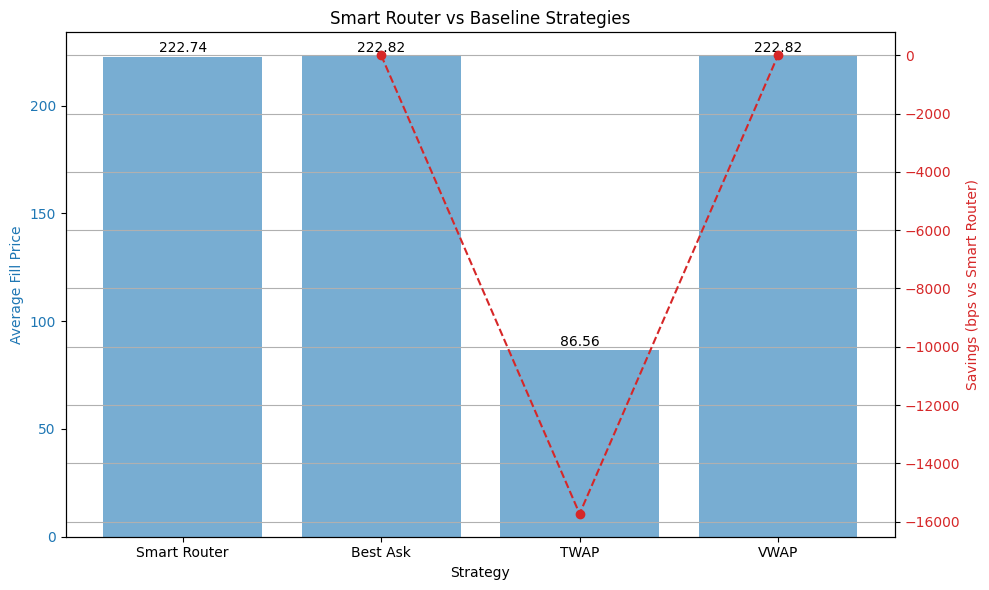

In [ ]:
import pandas as pd
import numpy as np
import json
from itertools import product
import matplotlib.pyplot as plt

# Constants
ORDER_SIZE = 5000
CHUNK = 100
PARAM_GRID = {
    "lambda_over": [0.01, 0.05, 0.1],
    "lambda_under": [0.01, 0.05, 0.1],
    "theta_queue": [0.01, 0.05, 0.1]
}

# Load and preprocess market data
df = pd.read_csv("l1_day.csv")
df = df.sort_values("ts_event")
df = df.dropna(subset=["ask_px_00", "ask_sz_00"])
df = df.groupby(["ts_event", "publisher_id"]).first().reset_index()
snapshots = df.groupby("ts_event")

def compute_cost(split, venues, order_size, lambda_over, lambda_under, theta_queue):
    executed = 0
    cash_spent = 0.0
    for i in range(len(venues)):
        exe = min(split[i], venues[i]["ask_size"])
        executed += exe
        cash_spent += exe * (venues[i]["ask"] + venues[i]["fee"])
        rebate = max(split[i] - exe, 0) * venues[i]["rebate"]
        cash_spent -= rebate
    underfill = max(order_size - executed, 0)
    overfill = max(executed - order_size, 0)
    risk_pen = theta_queue * (underfill + overfill)
    cost_pen = lambda_under * underfill + lambda_over * overfill
    return cash_spent + risk_pen + cost_pen

def allocate(order_size, venues, lambda_over, lambda_under, theta_queue):
    splits = [[]]
    for v in range(len(venues)):
        new_splits = []
        for alloc in splits:
            used = sum(alloc)
            max_v = min(order_size - used, venues[v]["ask_size"])
            for q in range(0, int(max_v) + 1, CHUNK):
                new_splits.append(alloc + [q])
        splits = new_splits

    best_cost = float("inf")
    best_split = []

    for alloc in splits:
        if sum(alloc) != order_size:
            continue
        cost = compute_cost(alloc, venues, order_size, lambda_over, lambda_under, theta_queue)
        if cost < best_cost:
            best_cost = cost
            best_split = alloc

    return best_split, best_cost

def get_snapshot_venues(snapshot_df):
    return [
        {
            "ask": row["ask_px_00"],
            "ask_size": row["ask_sz_00"],
            "fee": 0.0030,
            "rebate": 0.0020
        }
        for _, row in snapshot_df.iterrows()
    ]

def run_backtest(lambda_over, lambda_under, theta_queue):
    remaining = ORDER_SIZE
    total_spent = 0
    for _, snapshot in snapshots:
        venues = get_snapshot_venues(snapshot)
        alloc, _ = allocate(remaining, venues, lambda_over, lambda_under, theta_queue)
        for i in range(len(alloc)):
            filled = min(alloc[i], venues[i]["ask_size"])
            total_spent += filled * venues[i]["ask"]
            remaining -= filled
            if remaining <= 0:
                break
        if remaining <= 0:
            break
    avg_fill_price = total_spent / ORDER_SIZE
    return total_spent, avg_fill_price

best_result = {"total_spent": float("inf"), "params": None, "avg_price": None}
for lo, lu, tq in product(*PARAM_GRID.values()):
    spent, avg_price = run_backtest(lo, lu, tq)
    if spent < best_result["total_spent"]:
        best_result.update({
            "total_spent": spent,
            "params": {"lambda_over": lo, "lambda_under": lu, "theta_queue": tq},
            "avg_price": avg_price
        })

def best_ask_baseline():
    remaining = ORDER_SIZE
    total_spent = 0.0
    for _, snapshot in snapshots:
        venues = get_snapshot_venues(snapshot)
        venues = sorted(venues, key=lambda x: x["ask"])
        for venue in venues:
            buy_qty = min(venue["ask_size"], remaining)
            total_spent += buy_qty * venue["ask"]
            remaining -= buy_qty
            if remaining <= 0:
                break
        if remaining <= 0:
            break
    avg_price = total_spent / ORDER_SIZE
    return total_spent, avg_price

def twap_baseline(bucket_seconds=60):
    df["parsed_time"] = pd.to_datetime(df["ts_event"])
    df["time_bucket"] = df["parsed_time"].dt.floor(f"{bucket_seconds}s")
    grouped = df.groupby("time_bucket")
    shares_per_bucket = ORDER_SIZE // len(grouped)
    total_spent = 0
    remaining = ORDER_SIZE
    for _, group in grouped:
        if remaining <= 0:
            break
        snapshot = group.groupby("publisher_id").first().reset_index()
        venues = get_snapshot_venues(snapshot)
        venues = sorted(venues, key=lambda x: x["ask"])
        remaining_in_bucket = min(shares_per_bucket, remaining)
        for venue in venues:
            buy_qty = min(venue["ask_size"], remaining_in_bucket)
            total_spent += buy_qty * venue["ask"]
            remaining -= buy_qty
            remaining_in_bucket -= buy_qty
            if remaining <= 0:
                break
    avg_price = total_spent / ORDER_SIZE
    return total_spent, avg_price

def vwap_baseline():
    total_ask_volume = 0.0
    weighted_price_sum = 0.0
    remaining = ORDER_SIZE
    for _, snapshot in snapshots:
        if remaining <= 0:
            break
        venues = get_snapshot_venues(snapshot)
        ask_vol_sum = sum(v["ask_size"] for v in venues)
        if ask_vol_sum == 0:
            continue
        for venue in venues:
            weight = venue["ask_size"] / ask_vol_sum
            buy_qty = min(int(weight * ORDER_SIZE), venue["ask_size"], remaining)
            total_ask_volume += buy_qty
            weighted_price_sum += buy_qty * venue["ask"]
            remaining -= buy_qty
            if remaining <= 0:
                break
    avg_price = weighted_price_sum / ORDER_SIZE
    return weighted_price_sum, avg_price

# Baseline results
best_ask_cash, best_ask_avg = best_ask_baseline()
twap_cash, twap_avg = twap_baseline()
vwap_cash, vwap_avg = vwap_baseline()

savings = {
    "vs_best_ask": round((best_ask_avg - best_result["avg_price"]) / best_ask_avg * 10000, 2),
    "vs_twap": round((twap_avg - best_result["avg_price"]) / twap_avg * 10000, 2),
    "vs_vwap": round((vwap_avg - best_result["avg_price"]) / vwap_avg * 10000, 2)
}

result = {
    "best_params": best_result["params"],
    "smart_router": {
        "cash": best_result["total_spent"],
        "avg_fill_price": best_result["avg_price"]
    },
    "best_ask": {"cash": best_ask_cash, "avg_fill_price": best_ask_avg},
    "twap": {"cash": twap_cash, "avg_fill_price": twap_avg},
    "vwap": {"cash": vwap_cash, "avg_fill_price": vwap_avg},
    "savings_bps": savings
}

print(json.dumps(result, indent=2))

# --- Visualization ---
strategies = ["Smart Router", "Best Ask", "TWAP", "VWAP"]
avg_prices = [
    result["smart_router"]["avg_fill_price"],
    result["best_ask"]["avg_fill_price"],
    result["twap"]["avg_fill_price"],
    result["vwap"]["avg_fill_price"]
]
savings_bps = [
    0,
    result["savings_bps"]["vs_best_ask"],
    result["savings_bps"]["vs_twap"],
    result["savings_bps"]["vs_vwap"]
]

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Strategy')
ax1.set_ylabel('Average Fill Price', color=color)
bars = ax1.bar(strategies, avg_prices, color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title("Smart Router vs Baseline Strategies")

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, round(yval, 2), ha='center', va='bottom')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Savings (bps vs Smart Router)', color=color)
ax2.plot(strategies[1:], savings_bps[1:], marker='o', color=color, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.grid(True)
plt.savefig("results.png", dpi=300)
plt.savefig("results.pdf")